# 07 — Demo: Ceo pipeline na par slika

Kratka demonstracija celog toka: učitaj model → predvidi →
prebroj → uporedi sa ground truth, na par konkretnih test slika. 
Koristimo **M0 (baseline)** — najbolji model po evaluaciji
(F1=0.777 na test skupu).

```
slika -> model -> heatmap [0,1] -> prag (0.65, biran na validaciji)
      -> čišćenje (MIN_OBJECT_SIZE, popuni rupe) -> watershed -> centroidi ćelija -> broj
```

In [1]:
import sys
from pathlib import Path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image

from src import config
from src.data_loading import make_dataset
from src.models import build_model
from src.train import get_device
from src.postprocess import predict_mask, count_from_mask

In [2]:
device = get_device()
MODEL_NAME = "M0_baseline"

model = build_model(attention=False, activation="elu").to(device)
model.load_state_dict(torch.load(config.MODELS_DIR / f"{MODEL_NAME}.pth", map_location=device))
model.eval()
threshold = float((config.MODELS_DIR / f"{MODEL_NAME}_threshold.txt").read_text().strip())
print(f"Model: {MODEL_NAME}, threshold={threshold}, device={device}")

Model: M0_baseline, threshold=0.65, device=mps


In [ ]:
test_ds = make_dataset(split="test", form="full", augment=False, cache=False)
test_ids = [test_ds.samples[i][0] for i in range(len(test_ds))]

# tri primera: prazna/retka, srednja, gusta slika (raznovrsnost za demo)
counts = []
for i, iid in enumerate(test_ids):
    _, mask, _ = test_ds[i]
    counts.append((int(mask.sum().item() > 0) and int((np.array(Image.open(config.MASK_DIR/iid))>0).sum()), iid))
# gustina po broju foreground piksela je dovoljan proxy za izbor primera ovde
fg_counts = [(int((np.array(Image.open(config.MASK_DIR/iid)) > 0).sum()), iid) for iid in test_ids]
fg_counts.sort()

nonzero = [fc for fc in fg_counts if fc[0] > 0]    # izbegavemo prazne slike
sparse_iid = nonzero[len(nonzero)//10][1]      # retka (donji decil)
medium_iid = fg_counts[len(fg_counts)//2][1]       # srednja (medijana)
dense_iid  = fg_counts[-1][1]                       # najgušća

demo_ids = [sparse_iid, medium_iid, dense_iid]
print("Demo slike (retka, srednja, gusta):", demo_ids)

Demo slike (retka, srednja, gusta): ['Mar19bS1C1R2_VLPAGr_200x_y.png', 'Mar21bS1C2R3_VLPAGr_200x_y.png', 'MAR38S1C3R1_LHR_20_o.png']


In [12]:
def run_pipeline(iid):
    img = np.array(Image.open(config.IMG_DIR / iid).convert("RGB"))
    gt_mask = np.array(Image.open(config.MASK_DIR / iid)) > 0

    img_t = torch.from_numpy(img / 255.0).permute(2, 0, 1).float().unsqueeze(0)
    with torch.no_grad():
        heatmap = model(img_t.to(device)).cpu().numpy()[0, 0]

    pred_labeled, pred_centroids, n_pred = predict_mask(heatmap, threshold)
    gt_labeled, gt_centroids, n_true = count_from_mask(gt_mask)
    return img, heatmap, pred_labeled, pred_centroids, n_pred, gt_labeled, gt_centroids, n_true

results = {iid: run_pipeline(iid) for iid in demo_ids}
for iid, r in results.items():
    n_pred, n_true = r[4], r[7]
    print(f"{iid}: predviđeno={n_pred}, GT={n_true}, greška={abs(n_pred-n_true)}")

/Users/ana_velimirovic/Desktop/Ana-priv/ML/projekat/Fluorescent-neuronal-cell-counting/src/postprocess.py:43: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask = remove_small_objects(mask, min_size=min_size)


Mar19bS1C1R2_VLPAGr_200x_y.png: predviđeno=1, GT=2, greška=1
Mar21bS1C2R3_VLPAGr_200x_y.png: predviđeno=15, GT=6, greška=9
MAR38S1C3R1_LHR_20_o.png: predviđeno=48, GT=53, greška=5


## Vizuelizacija: slika, predikcija centara ćelija, GT centri

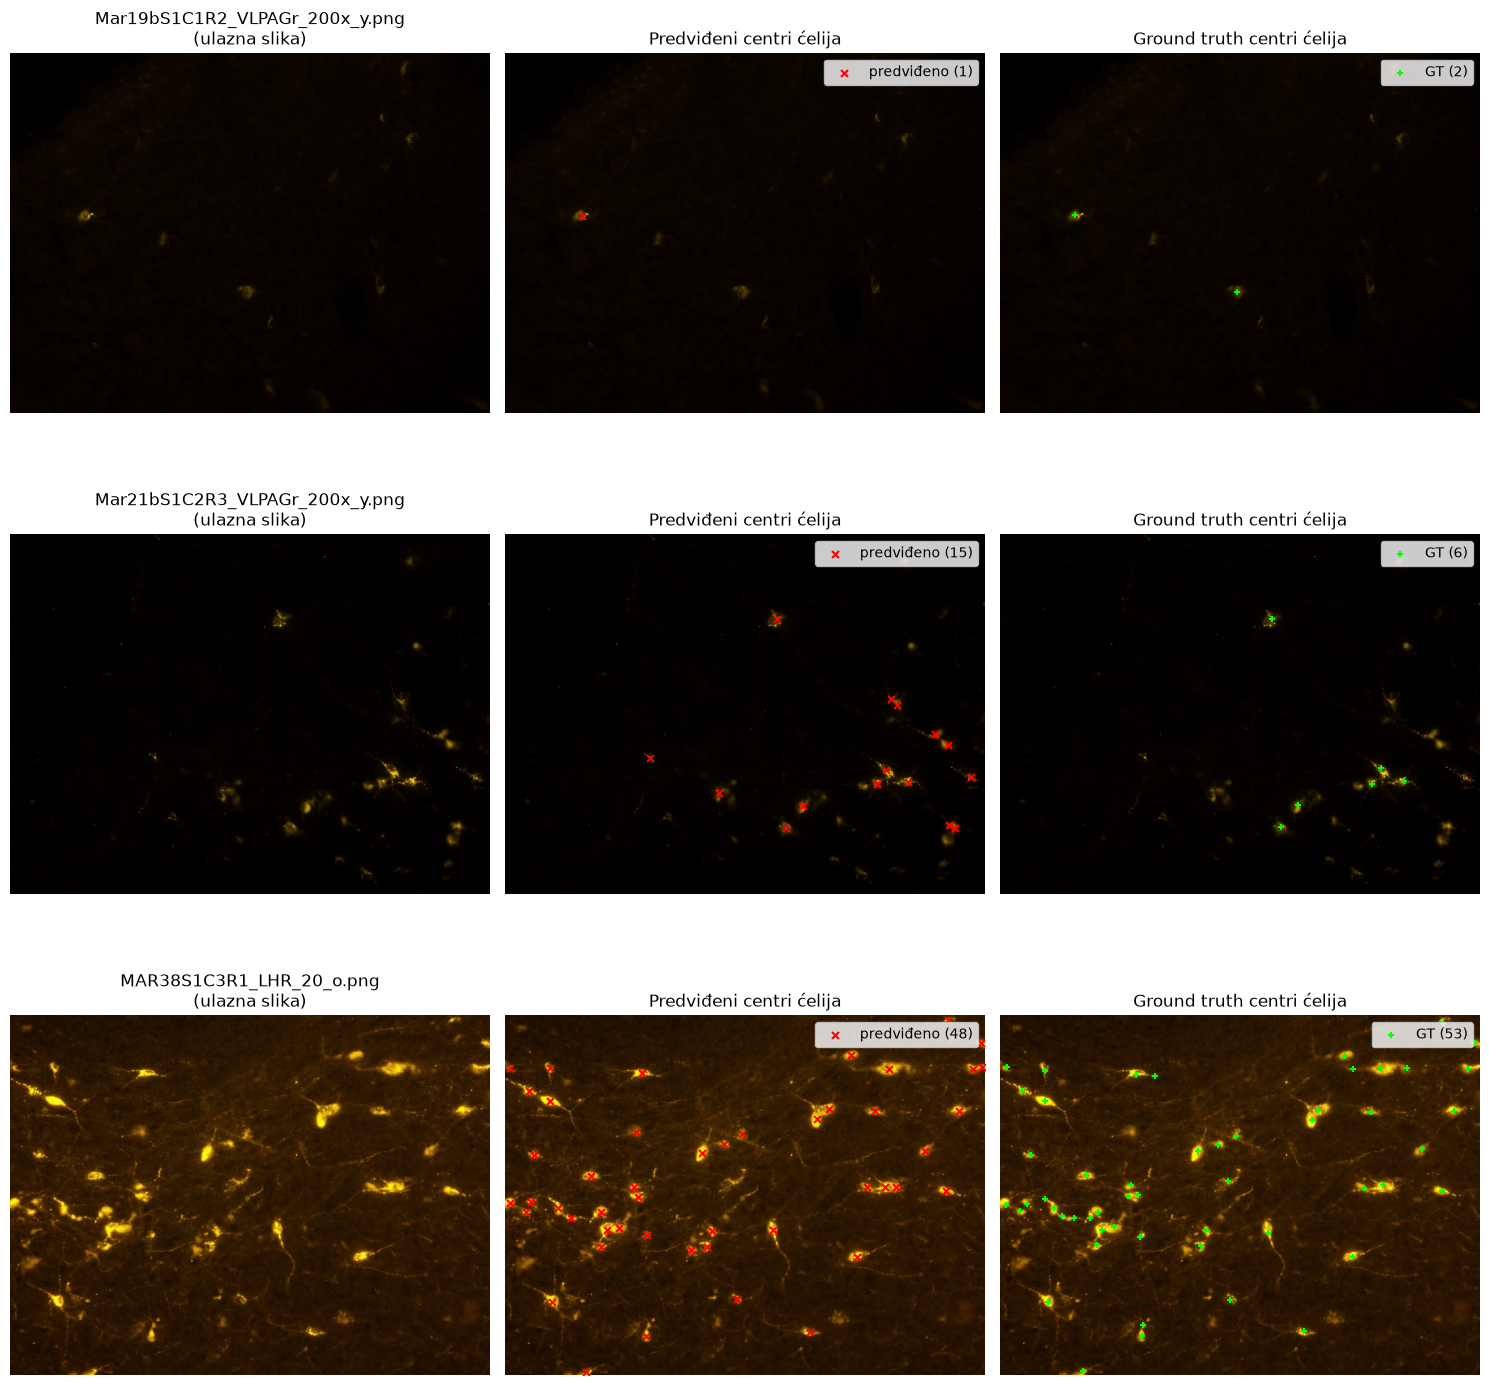

In [13]:
fig, axes = plt.subplots(len(demo_ids), 3, figsize=(15, 5 * len(demo_ids)))
for row, iid in enumerate(demo_ids):
    img, heatmap, pred_labeled, pred_centroids, n_pred, gt_labeled, gt_centroids, n_true = results[iid]

    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f"{iid}\n(ulazna slika)")

    axes[row, 1].imshow(img)
    if pred_centroids:
        ys, xs = zip(*pred_centroids)
        axes[row, 1].scatter(xs, ys, c="red", s=25, marker="x", label=f"predviđeno ({n_pred})")
    axes[row, 1].legend(loc="upper right")
    axes[row, 1].set_title("Predviđeni centri ćelija")

    axes[row, 2].imshow(img)
    if gt_centroids:
        ys, xs = zip(*gt_centroids)
        axes[row, 2].scatter(xs, ys, c="lime", s=25, marker="+", label=f"GT ({n_true})")
    axes[row, 2].legend(loc="upper right")
    axes[row, 2].set_title("Ground truth centri ćelija")

for a in axes.ravel():
    a.axis("off")
plt.tight_layout()
plt.show()

## M1 — Attention+ELU

In [14]:
MODEL_NAME_M1 = "M1_attention_elu"

model_m1 = build_model(attention=True, activation="elu").to(device)
model_m1.load_state_dict(torch.load(config.MODELS_DIR / f"{MODEL_NAME_M1}.pth", map_location=device))
model_m1.eval()
threshold_m1 = float((config.MODELS_DIR / f"{MODEL_NAME_M1}_threshold.txt").read_text().strip())
print(f"Model: {MODEL_NAME_M1}, threshold={threshold_m1}")

def run_pipeline_m1(iid):
    img = np.array(Image.open(config.IMG_DIR / iid).convert("RGB"))
    gt_mask = np.array(Image.open(config.MASK_DIR / iid)) > 0

    img_t = torch.from_numpy(img / 255.0).permute(2, 0, 1).float().unsqueeze(0)
    with torch.no_grad():
        heatmap = model_m1(img_t.to(device)).cpu().numpy()[0, 0]

    pred_labeled, pred_centroids, n_pred = predict_mask(heatmap, threshold_m1)
    gt_labeled, gt_centroids, n_true = count_from_mask(gt_mask)
    return img, heatmap, pred_labeled, pred_centroids, n_pred, gt_labeled, gt_centroids, n_true

results_m1 = {iid: run_pipeline_m1(iid) for iid in demo_ids}
for iid, r in results_m1.items():
    n_pred, n_true = r[4], r[7]
    print(f"{iid}: predviđeno={n_pred}, GT={n_true}, greška={abs(n_pred-n_true)}")

Model: M1_attention_elu, threshold=0.65
Mar19bS1C1R2_VLPAGr_200x_y.png: predviđeno=1, GT=2, greška=1
Mar21bS1C2R3_VLPAGr_200x_y.png: predviđeno=15, GT=6, greška=9
MAR38S1C3R1_LHR_20_o.png: predviđeno=39, GT=53, greška=14


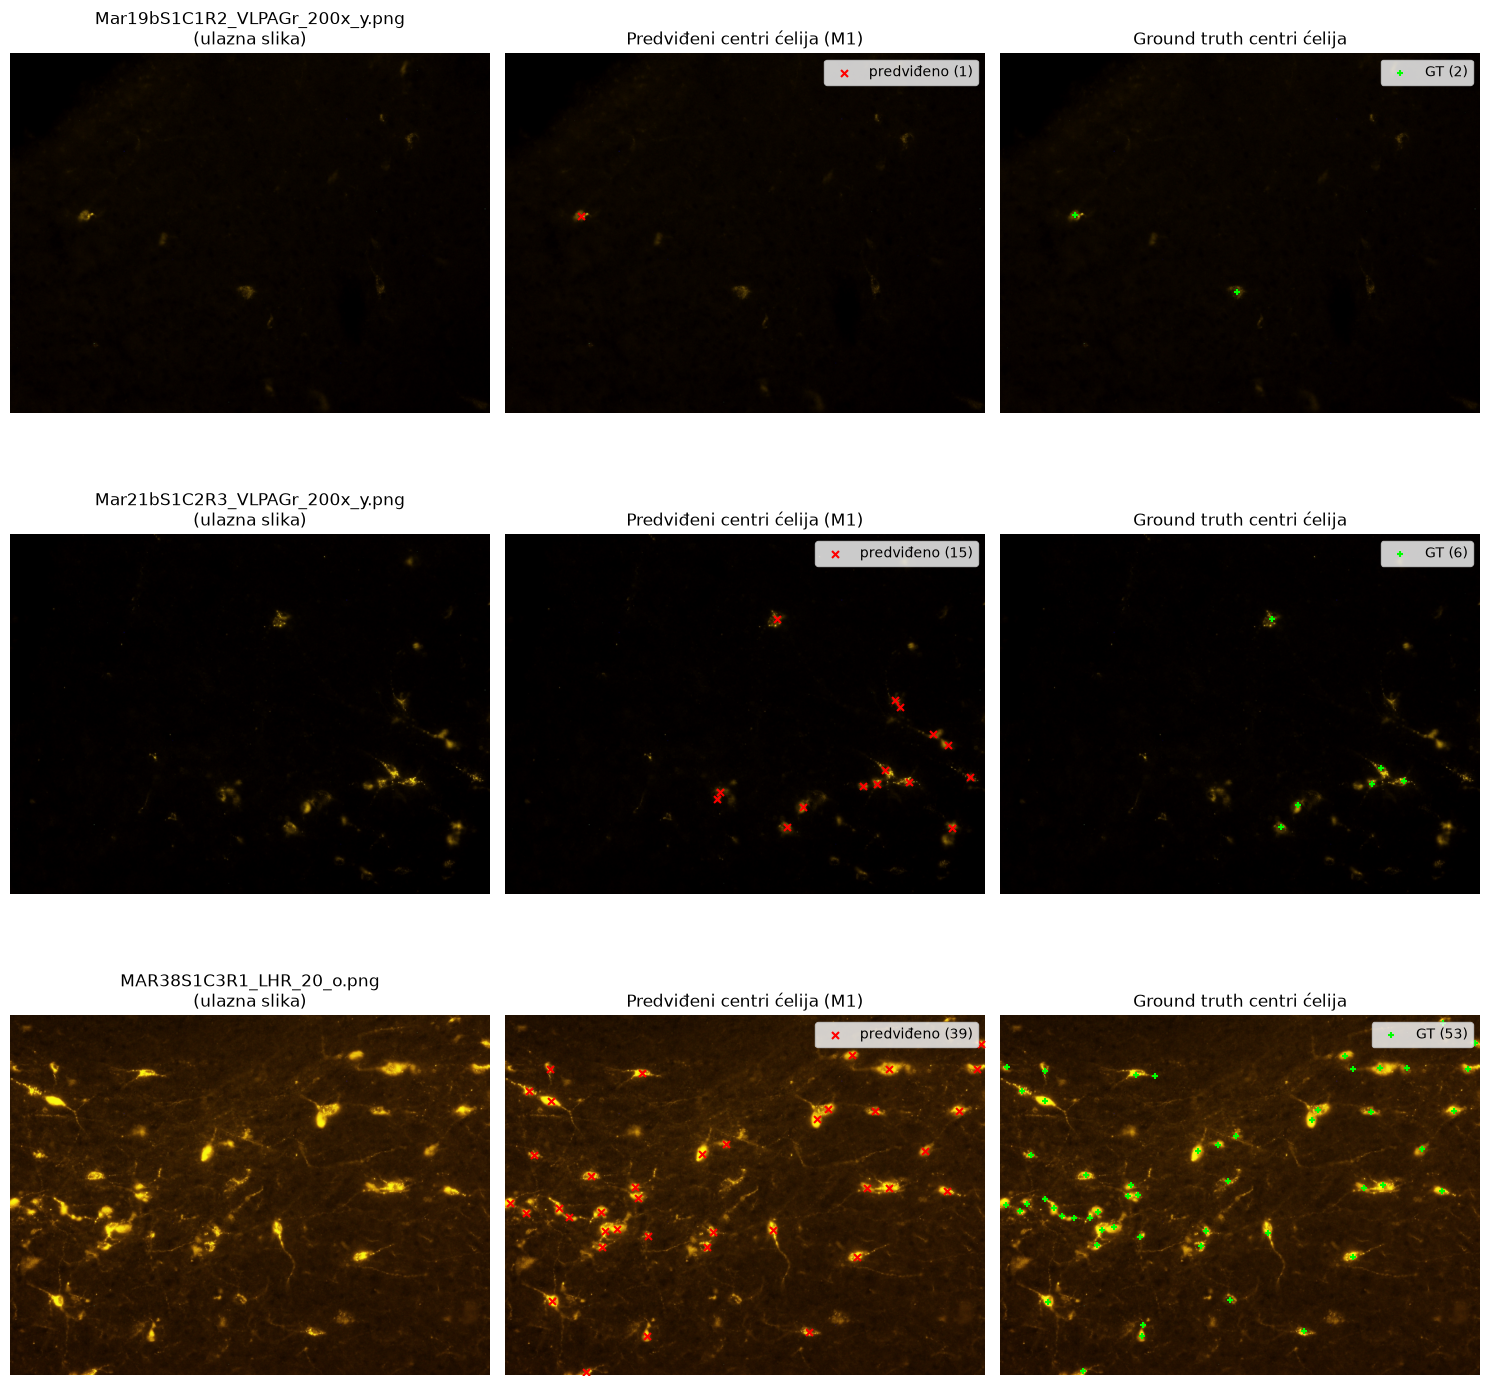

In [15]:
fig, axes = plt.subplots(len(demo_ids), 3, figsize=(15, 5 * len(demo_ids)))
for row, iid in enumerate(demo_ids):
    img, heatmap, pred_labeled, pred_centroids, n_pred, gt_labeled, gt_centroids, n_true = results_m1[iid]

    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f"{iid}\n(ulazna slika)")

    axes[row, 1].imshow(img)
    if pred_centroids:
        ys, xs = zip(*pred_centroids)
        axes[row, 1].scatter(xs, ys, c="red", s=25, marker="x", label=f"predviđeno ({n_pred})")
    axes[row, 1].legend(loc="upper right")
    axes[row, 1].set_title("Predviđeni centri ćelija (M1)")

    axes[row, 2].imshow(img)
    if gt_centroids:
        ys, xs = zip(*gt_centroids)
        axes[row, 2].scatter(xs, ys, c="lime", s=25, marker="+", label=f"GT ({n_true})")
    axes[row, 2].legend(loc="upper right")
    axes[row, 2].set_title("Ground truth centri ćelija")

for a in axes.ravel():
    a.axis("off")
plt.tight_layout()
plt.show()

## M2 — Attention+ReLU

In [16]:
MODEL_NAME_M2 = "M2_attention_relu"

model_m2 = build_model(attention=True, activation="relu").to(device)
model_m2.load_state_dict(torch.load(config.MODELS_DIR / f"{MODEL_NAME_M2}.pth", map_location=device))
model_m2.eval()
threshold_m2 = float((config.MODELS_DIR / f"{MODEL_NAME_M2}_threshold.txt").read_text().strip())
print(f"Model: {MODEL_NAME_M2}, threshold={threshold_m2}")

def run_pipeline_m2(iid):
    img = np.array(Image.open(config.IMG_DIR / iid).convert("RGB"))
    gt_mask = np.array(Image.open(config.MASK_DIR / iid)) > 0

    img_t = torch.from_numpy(img / 255.0).permute(2, 0, 1).float().unsqueeze(0)
    with torch.no_grad():
        heatmap = model_m2(img_t.to(device)).cpu().numpy()[0, 0]

    pred_labeled, pred_centroids, n_pred = predict_mask(heatmap, threshold_m2)
    gt_labeled, gt_centroids, n_true = count_from_mask(gt_mask)
    return img, heatmap, pred_labeled, pred_centroids, n_pred, gt_labeled, gt_centroids, n_true

results_m2 = {iid: run_pipeline_m2(iid) for iid in demo_ids}
for iid, r in results_m2.items():
    n_pred, n_true = r[4], r[7]
    print(f"{iid}: predviđeno={n_pred}, GT={n_true}, greška={abs(n_pred-n_true)}")

Model: M2_attention_relu, threshold=0.6
Mar19bS1C1R2_VLPAGr_200x_y.png: predviđeno=1, GT=2, greška=1
Mar21bS1C2R3_VLPAGr_200x_y.png: predviđeno=15, GT=6, greška=9
MAR38S1C3R1_LHR_20_o.png: predviđeno=46, GT=53, greška=7


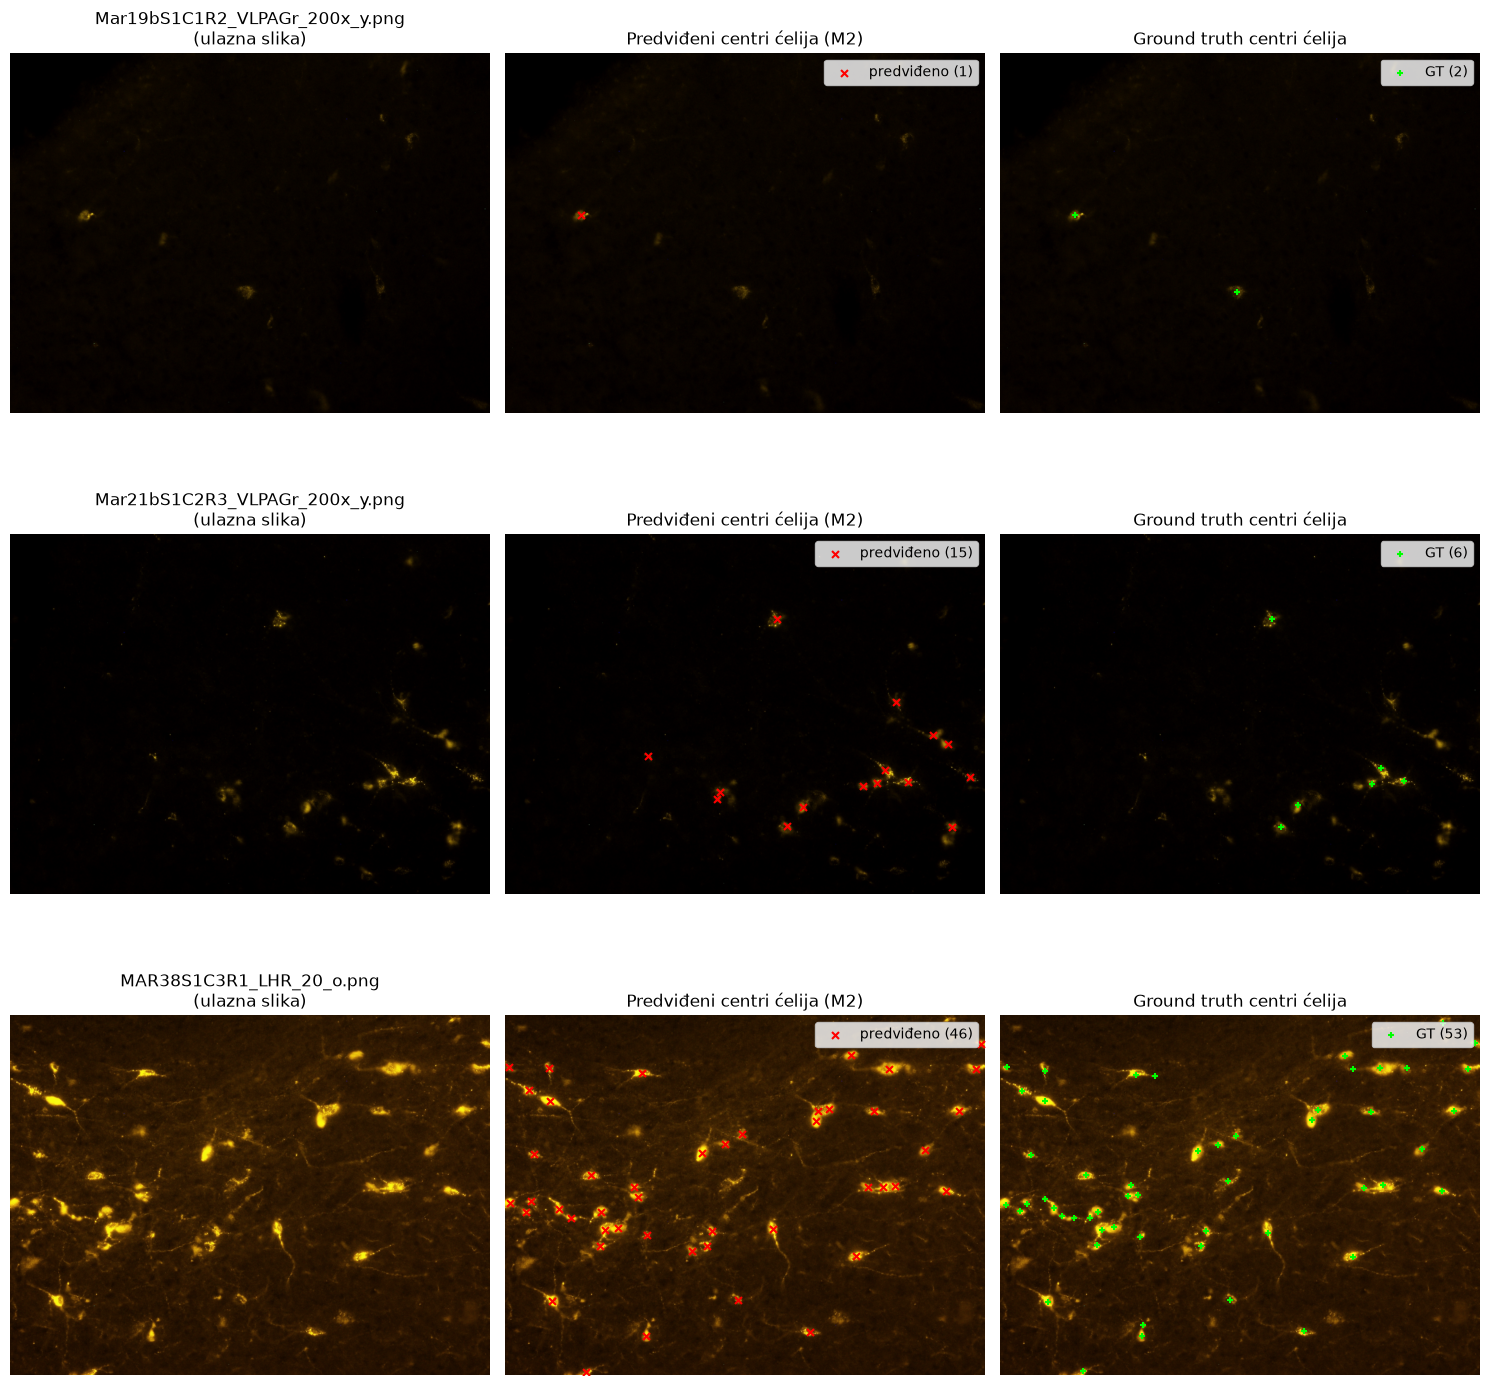

In [17]:
fig, axes = plt.subplots(len(demo_ids), 3, figsize=(15, 5 * len(demo_ids)))
for row, iid in enumerate(demo_ids):
    img, heatmap, pred_labeled, pred_centroids, n_pred, gt_labeled, gt_centroids, n_true = results_m2[iid]

    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f"{iid}\n(ulazna slika)")

    axes[row, 1].imshow(img)
    if pred_centroids:
        ys, xs = zip(*pred_centroids)
        axes[row, 1].scatter(xs, ys, c="red", s=25, marker="x", label=f"predviđeno ({n_pred})")
    axes[row, 1].legend(loc="upper right")
    axes[row, 1].set_title("Predviđeni centri ćelija (M2)")

    axes[row, 2].imshow(img)
    if gt_centroids:
        ys, xs = zip(*gt_centroids)
        axes[row, 2].scatter(xs, ys, c="lime", s=25, marker="+", label=f"GT ({n_true})")
    axes[row, 2].legend(loc="upper right")
    axes[row, 2].set_title("Ground truth centri ćelija")

for a in axes.ravel():
    a.axis("off")
plt.tight_layout()
plt.show()

## Rezime

Demonstriramo ceo tok (slika → heatmap → prag → čišćenje → watershed → broj i centri ćelija) na tri test slike izabrane po gustini (broj foreground piksela u GT maski) uz izbegavanje praznih: retka, srednja i gusta.

Rezultati (predviđeno / GT):
- **retka** (Mar19): 1 / 2
- **srednja** (Mar21): 15 / 6
- **gusta** (MAR38): M0 48, M1 39, M2 46 / GT 53

Na svim primerima pipeline radi end-to-end i daje broj i lokacije ćelija.

Ovo je ilustrativan prikaz na pojedinačnim slikama. Pune agregatne metrike na celom test skupu (70 slika) i poređenje modela nalaze se u `06_evaluation_and_comparison.ipynb`.